In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import cv2
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

2026-07-01 14:21:02.710279: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 14:21:03.848642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-01 14:21:08.179811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.20.0


In [2]:
DATASET_PATH = "SolvaDataset_200_v3"

print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset exists: True


In [3]:
classes = sorted(os.listdir(DATASET_PATH))

print(f"Total Classes: {len(classes)}\n")

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(folder):
        print(f"{cls:25} {len(os.listdir(folder))}")

Total Classes: 15

Ammeter                   200
ac_src                    199
battery                   200
cap                       200
curr_src                  200
dc_volt_src_1             199
dc_volt_src_2             199
dep_curr_src              197
dep_volt                  196
diode                     200
gnd_1                     182
gnd_2                     198
inductor                  194
resistor                  188
voltmeter                 200


In [4]:
deleted = 0

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if "Zone.Identifier" in file:

            path = os.path.join(root, file)

            os.remove(path)

            deleted += 1

print(f"Deleted {deleted} Zone.Identifier files!")

Deleted 0 Zone.Identifier files!


In [5]:
for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    print(cls, len(os.listdir(folder)))

Ammeter 200
ac_src 199
battery 200
cap 200
curr_src 200
dc_volt_src_1 199
dc_volt_src_2 199
dep_curr_src 197
dep_volt 196
diode 200
gnd_1 182
gnd_2 198
inductor 194
resistor 188
voltmeter 200


In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
train_dataset = tf.keras.utils.image_dataset_from_directory(DATASET_PATH,validation_split=0.2,subset="training",seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)

validation_dataset = tf.keras.utils.image_dataset_from_directory(DATASET_PATH,validation_split=0.2,subset="validation",seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)

Found 2952 files belonging to 15 classes.
Using 2362 files for training.


I0000 00:00:1782915675.340549    1337 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2952 files belonging to 15 classes.
Using 590 files for validation.


In [7]:
class_names = train_dataset.class_names
print(class_names)

['Ammeter', 'ac_src', 'battery', 'cap', 'curr_src', 'dc_volt_src_1', 'dc_volt_src_2', 'dep_curr_src', 'dep_volt', 'diode', 'gnd_1', 'gnd_2', 'inductor', 'resistor', 'voltmeter']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")

In [10]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [11]:
inputs = keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(
    len(class_names),
    activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [13]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor="val_accuracy")

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1)

In [14]:
mobile = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15


2026-07-01 14:21:41.395830: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:15: Filling up shuffle buffer (this may take a while): 53 of 1000
2026-07-01 14:21:44.155831: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-07-01 14:21:45.626314: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


74/74 ━━━━━━━━━━━━━━━━━━━━ 57s 355ms/step - accuracy: 0.4848 - loss: 1.5599 - val_accuracy: 0.6678 - val_loss: 0.8930 - learning_rate: 0.0010
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 173ms/step - accuracy: 0.7396 - loss: 0.7623 - val_accuracy: 0.8034 - val_loss: 0.5925 - learning_rate: 0.0010
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - accuracy: 0.7985 - loss: 0.5912 - val_accuracy: 0.8119 - val_loss: 0.5378 - learning_rate: 0.0010
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.8264 - loss: 0.4976 - val_accuracy: 0.8492 - val_loss: 0.4617 - learning_rate: 0.0010
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8493 - loss: 0.4375 - val_accuracy: 0.8424 - val_loss: 0.4242 - learning_rate: 0.0010
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 173ms/step - accuracy: 0.8599 - loss: 0.4065 - val_accuracy: 0.8322 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.8734 - loss: 0.3719 - val_

In [15]:
model.save("CircuitSense_MobileNetV2.keras")

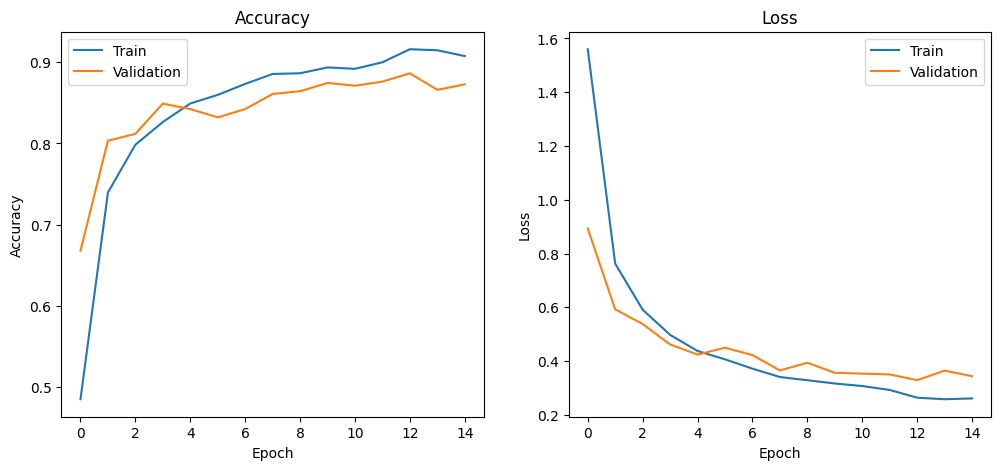

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mobile.history['accuracy'], label='Train')
plt.plot(mobile.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(mobile.history['loss'], label='Train')
plt.plot(mobile.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [17]:
y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

2026-07-01 14:26:00.077446: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

      Ammeter       0.78      0.84      0.81        37
       ac_src       0.92      0.83      0.87        29
      battery       0.97      0.83      0.89        35
          cap       0.90      0.83      0.86        46
     curr_src       0.88      0.71      0.79        42
dc_volt_src_1       0.73      0.96      0.83        48
dc_volt_src_2       0.68      0.88      0.77        34
 dep_curr_src       0.93      0.93      0.93        41
     dep_volt       0.93      0.93      0.93        46
        diode       1.00      1.00      1.00        36
        gnd_1       1.00      1.00      1.00        29
        gnd_2       1.00      1.00      1.00        37
     inductor       0.97      0.85      0.91        40
     resistor       0.86      0.97      0.91        32
    voltmeter       0.92      0.81      0.86        58

     accuracy                           0.89       590
    macro avg       0.90      0.89      0.89       590
 weighte

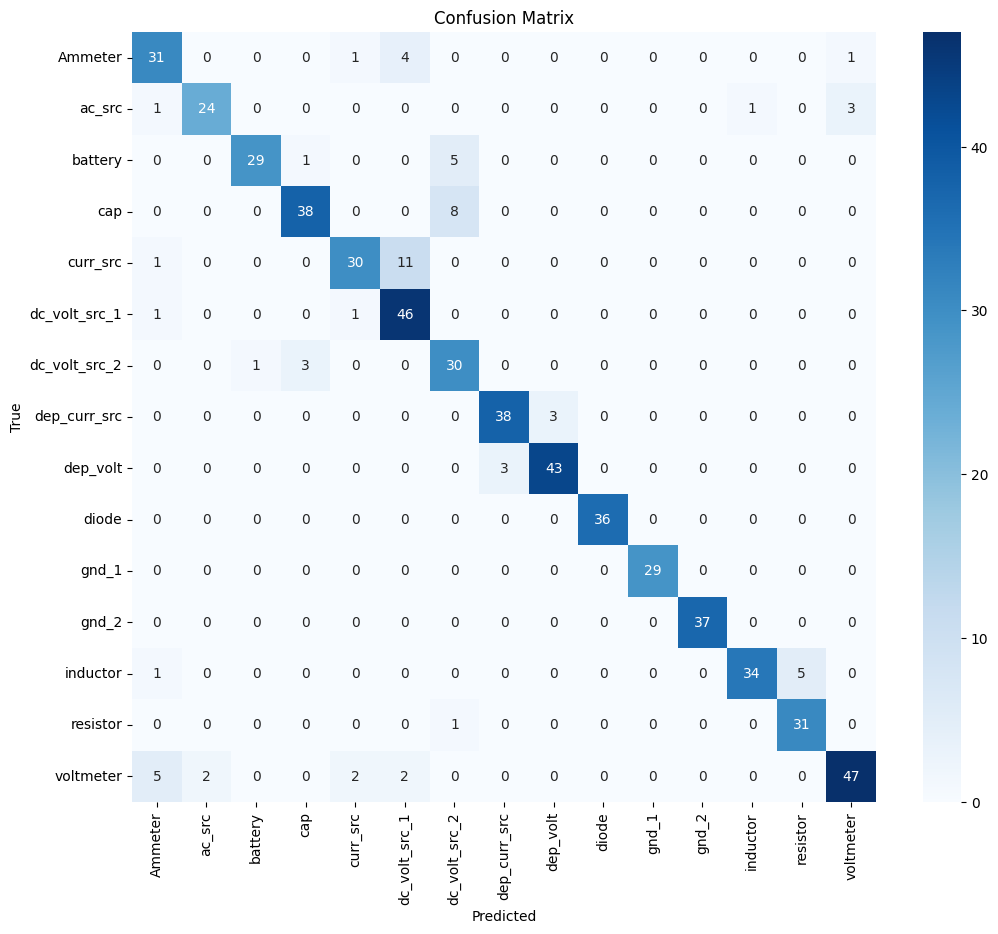

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [20]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

mobile_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[checkpoint,early_stop,reduce_lr])

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 58s 407ms/step - accuracy: 0.7257 - loss: 0.8738 - val_accuracy: 0.8797 - val_loss: 0.3365 - learning_rate: 1.0000e-05
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8151 - loss: 0.5459
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step - accuracy: 0.8285 - loss: 0.5146 - val_accuracy: 0.8576 - val_loss: 0.3740 - learning_rate: 1.0000e-05
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 257ms/step - accuracy: 0.8620 - loss: 0.4134 - val_accuracy: 0.8610 - val_loss: 0.3619 - learning_rate: 2.0000e-06
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8508 - loss: 0.4327
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.8603 - loss: 0.4107 - val_accuracy: 0.8627 - val_loss: 0.3544 - learning_rate: 2.0000e-06
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 242ms/step - accuracy: 0.85

In [21]:
model = keras.models.load_model("CircuitSense_MobileNetV2.keras")

In [36]:
def predict_image(image_path):

    img = keras.utils.load_img(
        image_path,
        target_size=(224,224))

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    top3 = np.argsort(predictions)[::-1][:3]

    print("="*50)
    print("Prediction Results")
    print("="*50)

    print("\nTop 3 Predictions:\n")

    for idx in top3:
        print(f"{class_names[idx]:20} {predictions[idx]*100:.2f}%")

    best = top3[0]

    print("\nFinal Prediction")
    print(f"Class: {class_names[best]}")
    print(f"Confidence : {predictions[best]*100:.2f}%")

    return class_names[best], predictions

In [37]:
component_info = {

    "resistor": {
        "Function": "Limits current flow in a circuit.",
        "Unit": "Ohm (Ω)",
        "Applications": "Current limiting, Voltage divider, Pull-up/Pull-down"
    },

    "cap": {
        "Function": "Stores electrical charge.",
        "Unit": "Farad (F)",
        "Applications": "Filtering, Coupling, Timing"
    },

    "inductor": {
        "Function": "Stores energy in a magnetic field.",
        "Unit": "Henry (H)",
        "Applications": "Filters, SMPS, Chokes"
    },

    "diode": {
        "Function": "Allows current in one direction.",
        "Unit": "-",
        "Applications": "Rectifiers, Reverse polarity protection"
    },

    "battery": {
        "Function": "Provides DC electrical energy.",
        "Unit": "Volt (V)",
        "Applications": "Power source"
    },

    "ammeter": {
        "Function": "Measures electric current.",
        "Unit": "Ampere (A)",
        "Applications": "Current measurement"
    },

    "voltmeter": {
        "Function": "Measures voltage.",
        "Unit": "Volt (V)",
        "Applications": "Voltage measurement"
    },

    "ac_src": {
        "Function": "Alternating voltage source.",
        "Unit": "Volt (V)",
        "Applications": "AC power supply"
    },

    "curr_src": {
        "Function": "Provides constant current.",
        "Unit": "Ampere (A)",
        "Applications": "Current source circuits"
    },

    "dc_volt_src_1": {
        "Function": "DC voltage source.",
        "Unit": "Volt (V)",
        "Applications": "Power supply"
    },

    "dc_volt_src_2": {
        "Function": "DC voltage source.",
        "Unit": "Volt (V)",
        "Applications": "Power supply"
    },

    "dep_curr_src": {
        "Function": "Dependent current source.",
        "Unit": "Ampere (A)",
        "Applications": "Circuit analysis"
    },

    "dep_volt": {
        "Function": "Dependent voltage source.",
        "Unit": "Volt (V)",
        "Applications": "Circuit analysis"
    },

    "gnd_1": {
        "Function": "Ground reference.",
        "Unit": "-",
        "Applications": "Common reference node"
    },

    "gnd_2": {
        "Function": "Ground reference.",
        "Unit": "-",
        "Applications": "Common reference node"
    }

}

In [38]:
def predict_image(image_path):

    img = keras.utils.load_img(image_path, target_size=(224,224))
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    top3 = np.argsort(predictions)[::-1][:3]

    best = top3[0]

    symbol = class_names[best]

    print("="*60)
    print("CircuitSense Prediction")
    print("="*60)

    print(f"\nPredicted Symbol : {symbol}")
    print(f"Confidence       : {predictions[best]*100:.2f}%")

    print("\nTop 3 Predictions")

    for idx in top3:
        print(f"{class_names[idx]:20} {predictions[idx]*100:.2f}%")

    if symbol in component_info:

        info = component_info[symbol]

        print("\nFunction")
        print(info["Function"])

        print("\nUnit")
        print(info["Unit"])

        print("\nApplications")
        print(info["Applications"])

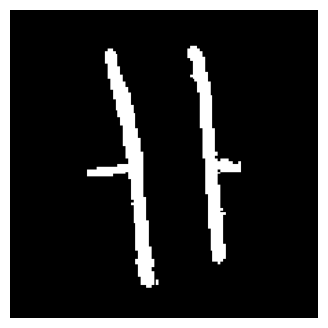

CircuitSense Prediction

Predicted Symbol : cap
Confidence       : 96.31%

Top 3 Predictions
cap                  96.31%
dc_volt_src_2        3.58%
gnd_2                0.05%

Function
Stores electrical charge.

Unit
Farad (F)

Applications
Filtering, Coupling, Timing


In [39]:
predict_image("SolvaDataset_200_v3/cap/132.bmp")